# Alloy health -- head-end data-collection status

Alloy is the collection layer that bridges two worlds: it **scrapes/receives** telemetry
in and **writes** it out to Mimir and Loki. If it drops, everything downstream goes blind
while looking healthy, so this notebook watches both sides: component/pod health, the
remote-write path to Mimir, the Loki write path, the OTLP receiver that ingests the edge
(Synology/Proxmox) feeds, scrape-target and blackbox-probe health, plus Alloy's own logs
and alerts. No-monitoring variant for when Alloy itself is down:
[alloy-nomon.ipynb](alloy-nomon.ipynb).

Alloy self-metrics are scraped **into Mimir**; the notebook reads them via `mimir-gateway`.
That they are fresh at all is itself an end-to-end proof the Alloy->Mimir metrics pipeline
works. Checks are informed by the deployed **alloy-mixin**; zero-thresholds
(unhealthy>0, refused>0, dropped>0, probe down) are self-evident and labeled as such.

Design: [tiles#651](https://github.com/symmatree/tiles/issues/651),
[docs/notebooks.md](../docs/notebooks.md), `facts/notebook-analysis/design-intent.md`.

Run from `notebooks/`: `jupyter nbconvert --to notebook --execute --inplace alloy-health.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # Alloy self-metrics are scraped INTO Mimir
loki_url = "http://loki.loki.svc:3100"        # for Alloy's own logs
tenant = "tiles"       # X-Scope-OrgID for Mimir and Loki
namespace = "alloy"    # namespace scoping for logs, alerts, kube metrics
lookback_hours = 24
range_step_s = 300
log_sample_lines = 100
capture_file = ""      # replay a prior raw capture JSON instead of querying live
output_dir = ""        # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'alloy-health'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, loki_url=loki_url,
                  tenant=tenant, namespace=namespace, lookback_hours=lookback_hours,
                  range_step_s=range_step_s, log_sample_lines=log_sample_lines)
tenant, namespace = cap.meta['tenant'], cap.meta['namespace']
lookback_hours, step = cap.meta['lookback_hours'], cap.meta['range_step_s']
mm = nbc.Mimir(cap, cap.meta['mimir_url'], tenant)
lk = nbc.Loki(cap, cap.meta['loki_url'], tenant)
print(f"mimir: {cap.meta['mimir_url']}  loki: {cap.meta['loki_url']}  tenant: {tenant}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  loki: http://loki.loki.svc:3100  tenant: tiles  live


In [3]:
# --- ASSUMPTIONS: verify the instruments before trusting any reading ---
# Fatal (whole notebook unassessable): Alloy self-monitoring absent/stale -- if Alloy's
# own metrics are not fresh in Mimir the head-end is either dead or unscraped, and every
# reading below is untrustworthy. Non-fatal: kube_*/cadvisor/Loki gaps degrade own section.
assumption_warnings = []
STALE_S = 600

binfo = mm.q('buildinfo', 'alloy_build_info')
alloy_version = binfo[0]['metric'].get('version', 'unknown') if binfo else 'unknown'
alloy_instances = len(binfo)

freshness = {
    'alloy self-monitoring': 'max(timestamp(alloy_component_controller_running_components))',
    'kube-state-metrics (alloy ns)': f'max(timestamp(kube_pod_info{{namespace="{namespace}"}}))',
    'cadvisor (alloy ns)': f'max(timestamp(container_memory_working_set_bytes{{namespace="{namespace}"}}))',
}
inst_age = {}
for inst, query in freshness.items():
    ts = nbc.val(mm.q(f'fresh: {inst}', query))
    inst_age[inst] = cap.now - ts if not np.isnan(ts) else np.inf
try:
    probe = lk.lines('fresh: alloy (alloy ns logs)', f'{{namespace="{namespace}"}}', 1, 1)
    inst_age['alloy (alloy ns logs)'] = cap.now - probe[0][0].timestamp() if probe else np.inf
except Exception:
    inst_age['alloy (alloy ns logs)'] = np.inf

print("=== ASSUMPTIONS ===")
print(f"  alloy {alloy_version}, {alloy_instances} reporting instances")
for inst, age in inst_age.items():
    status = 'MISSING' if np.isinf(age) else f"newest sample {age:.0f}s old" + (' -- STALE' if age > STALE_S else '')
    print(f"  {inst:<32} {status}")

self_age = inst_age['alloy self-monitoring']
if np.isinf(self_age) or self_age > STALE_S:
    raise RuntimeError(f"unassessable: alloy self-monitoring stale or absent ({self_age:.0f}s) "
                       f"-- see alloy-nomon.ipynb")
for inst, age in inst_age.items():
    if inst != 'alloy self-monitoring' and (np.isinf(age) or age > STALE_S):
        assumption_warnings.append(f"{inst} stale/missing ({age:.0f}s) -- its section is degraded")

=== ASSUMPTIONS ===
  alloy v1.12.1, 10 reporting instances
  alloy self-monitoring            newest sample 12s old
  kube-state-metrics (alloy ns)    newest sample 48s old
  cadvisor (alloy ns)              newest sample 2s old
  alloy (alloy ns logs)            newest sample 2s old


In [4]:
# --- CAPTURE: fetch the complete observation up front, before any analysis ---
# Component & pod health
comp_health = nbc.by(mm.q('components_by_health', 'sum by (health_type) (alloy_component_controller_running_components)'), 'health_type')
comp_unhealthy_by_pod = nbc.by(mm.q('unhealthy_by_pod', 'sum by (pod) (alloy_component_controller_running_components{health_type="unhealthy"})'), 'pod')
restarts = nbc.by(mm.q('restarts_by_pod', f'sum by (pod) (kube_pod_container_status_restarts_total{{namespace="{namespace}"}})'), 'pod')
last_term = mm.q('last_terminated_reason', f'kube_pod_container_status_last_terminated_reason{{namespace="{namespace}"}} == 1')
crashloop = mm.q('crashloop', f'kube_pod_container_status_waiting_reason{{namespace="{namespace}", reason="CrashLoopBackOff"}} == 1')
mem_ws = nbc.by(mm.q('mem_working_set_by_pod', f'sum by (pod) (container_memory_working_set_bytes{{namespace="{namespace}", container!=""}})'), 'pod')
mem_lim = nbc.by(mm.q('mem_limit_by_pod', f'sum by (pod) (kube_pod_container_resource_limits{{namespace="{namespace}", resource="memory"}})'), 'pod')

# Remote-write to Mimir (the write-out world)
rw_failed = nbc.val(mm.q('rw_samples_failed', 'sum(rate(prometheus_remote_storage_samples_failed_total[5m]))'), 0.0)
rw_pending = nbc.val(mm.q('rw_samples_pending', 'sum(prometheus_remote_storage_samples_pending)'), 0.0)
rw_shards = nbc.val(mm.q('rw_shards', 'sum(prometheus_remote_storage_shards)'), np.nan)
rw_highest_sent = nbc.val(mm.q('rw_highest_sent', 'max(prometheus_remote_storage_queue_highest_sent_timestamp_seconds)'), np.nan)
f_rw_failed = nbc.frame(mm.qr('rw_failed_trend', 'sum(rate(prometheus_remote_storage_samples_failed_total[5m]))', lookback_hours, step), None)

# Loki write path
loki_dropped = nbc.val(mm.q('loki_dropped', 'sum(rate(loki_write_dropped_entries_total[5m]))'), 0.0)
loki_sent = nbc.val(mm.q('loki_sent', 'sum(rate(loki_write_sent_entries_total[5m]))'), 0.0)
loki_retries = nbc.val(mm.q('loki_retries', 'sum(rate(loki_write_batch_retries_total[5m]))'), 0.0)
f_loki_dropped = nbc.frame(mm.qr('loki_dropped_trend', 'sum(rate(loki_write_dropped_entries_total[5m]))', lookback_hours, step), None)

# OTLP receiver -- the edge (Synology/Proxmox) ingest door
otel_acc_m = nbc.val(mm.q('otel_accepted_metrics', 'sum(rate(otelcol_receiver_accepted_metric_points_total[5m]))'), 0.0)
otel_ref_m = nbc.val(mm.q('otel_refused_metrics', 'sum(rate(otelcol_receiver_refused_metric_points_total[5m]))'), 0.0)
otel_acc_l = nbc.val(mm.q('otel_accepted_logs', 'sum(rate(otelcol_receiver_accepted_log_records_total[5m]))'), 0.0)
otel_ref_l = nbc.val(mm.q('otel_refused_logs', 'sum(rate(otelcol_receiver_refused_log_records_total[5m]))'), 0.0)
f_otel = nbc.frame(mm.qr('otel_trend',
    'label_replace(sum(rate(otelcol_receiver_accepted_metric_points_total[5m])), "k","accepted","","")'
    ' or label_replace(sum(rate(otelcol_receiver_refused_metric_points_total[5m])), "k","refused","","")', lookback_hours, step), 'k')

# Scrape targets (alloy's scrape-in world) & blackbox probes
targets_up = nbc.val(mm.q('targets_up', 'count(up)'), np.nan)
targets_down_q = mm.q('targets_down', 'up == 0')
probe_success = mm.q('probe_success', 'probe_success')

# Alloy's own logs + alerts
f_loglevel = nbc.frame(lk.metric_range('log_volume_by_level',
    f'sum by (detected_level) (count_over_time({{namespace="{namespace}"}}[10m]))', lookback_hours, 600), 'detected_level')
log_errwarn = lk.lines('log_errwarn_sample', f'{{namespace="{namespace}"}} | detected_level=~"error|warn"', lookback_hours, 50)
log_tail = lk.lines('log_tail_sample', f'{{namespace="{namespace}"}}', lookback_hours, log_sample_lines)
am_rec = mm.get('alertmanager_alerts', '/alertmanager/api/v2/alerts')
am_alerts = am_rec.get('json', []) if 'json' in am_rec else []
alerts_ns_24h = mm.q('alerts_ns_24h', f'sum by (alertname) (count_over_time(ALERTS{{namespace="{namespace}", alertstate="firing"}}[24h]))')
print(f"captured {len(cap.data['calls'])} raw calls")

captured 34 raw calls


In [5]:
# --- COMPONENT & POD HEALTH: unhealthy components, crashloops, restarts, memory ---
healthy = int(comp_health.get('healthy', 0))
unhealthy = int(comp_health.get('unhealthy', 0))
print(f"alloy components: {healthy} healthy, {unhealthy} unhealthy"
      + (f"  (unhealthy on: { {p: int(v) for p, v in comp_unhealthy_by_pod.items()} })" if unhealthy else ""))

pods = pd.DataFrame({'mem_mb': pd.Series(mem_ws) / 2**20,
                     'limit_mb': pd.Series(mem_lim) / 2**20,
                     'restarts': pd.Series(restarts)})
pods['last_term'] = pd.Series({r['metric']['pod']: r['metric']['reason'] for r in last_term})
pods = pods.sort_values('restarts', ascending=False)
print(pods.to_string(float_format=lambda v: f'{v:,.0f}', na_rep='-'))

crashloopers = sorted({r['metric']['pod'] for r in crashloop})
oom_pods = sorted(pods[pods['last_term'] == 'OOMKilled'].index)
print(f"CrashLoopBackOff now: {crashloopers or 'none'}")
print(f"last termination OOMKilled: {oom_pods or 'none'}")

alloy components: 154 healthy, 8 unhealthy  (unhealthy on: {'alloy-alloy-logs-56lvd': 1, 'alloy-alloy-logs-7hwcs': 1, 'alloy-alloy-logs-d2d5j': 1, 'alloy-alloy-logs-fs5d9': 1, 'alloy-alloy-logs-fw8r5': 1, 'alloy-alloy-logs-vptfn': 1, 'alloy-alloy-logs-wtnh5': 1, 'alloy-alloy-logs-xkpvc': 1})
                                           mem_mb  limit_mb  restarts               last_term
alloy-alloy-singleton-6bb9d87c89-qctbn          9       256     1,321                   Error
alloy-alloy-singleton-84894dfdb8-gpkff         12       256     1,139                   Error
alloy-alloy-singleton-84894dfdb8-pxs2s          -       256       160              StartError
alloy-kube-state-metrics-5fd87c5d6f-mv22j       -         -        57                   Error
alloy-alloy-logs-vptfn                        148       384        16                   Error
alloy-alloy-operator-69c77c47c8-zjwxp          66         -         7                   Error
alloy-alloy-logs-fs5d9                         92

remote_write: 0.000 samples/s failed, 814 pending, 2 shards, write lag 30s
  (lag = now - highest-sent timestamp; a steadily growing lag or nonzero failures means samples are backing up upstream of Mimir)


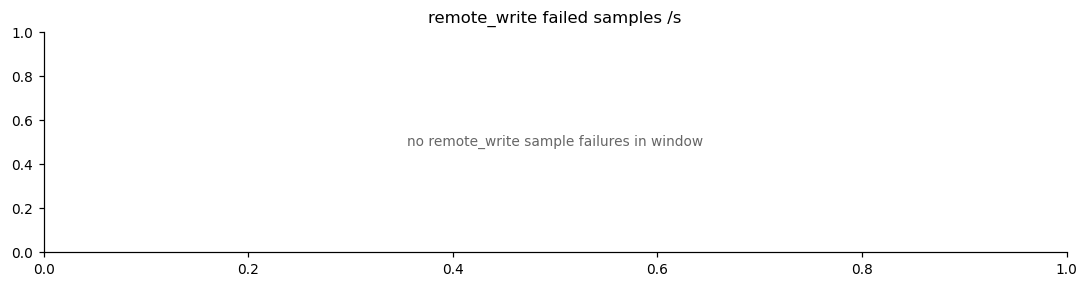

In [6]:
# --- REMOTE-WRITE TO MIMIR: is the write-out keeping up? ---
rw_lag = cap.now - rw_highest_sent if not np.isnan(rw_highest_sent) else np.inf
print(f"remote_write: {rw_failed:.3f} samples/s failed, {rw_pending:,.0f} pending, "
      f"{rw_shards:.0f} shards, write lag {rw_lag:.0f}s")
print("  (lag = now - highest-sent timestamp; a steadily growing lag or nonzero failures "
      "means samples are backing up upstream of Mimir)")

fig, ax = plt.subplots(figsize=(12, 2.6))
fr = f_rw_failed['value'] if not f_rw_failed.empty else pd.Series(dtype=float)
if fr.notna().any() and fr.max() > 0:
    ax.plot(fr.index, fr, color='C3', lw=2, label='failed samples/s')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'no remote_write sample failures in window', ha='center', va='center',
            transform=ax.transAxes, color='0.4')
    ax.grid(False)
ax.set_title('remote_write failed samples /s')
nbc.show(fig)

In [7]:
# --- LOKI WRITE PATH: dropped entries are lost logs ---
print(f"loki.write: {loki_sent:,.1f} entries/s sent, {loki_dropped:.3f}/s dropped, "
      f"{loki_retries:.3f}/s batch retries")
fd = f_loki_dropped['value'] if not f_loki_dropped.empty else pd.Series(dtype=float)
if fd.notna().any() and fd.max() > 0:
    print(f"  WARNING: dropped entries present in window (max {fd.max():.3f}/s) -- lost logs")

loki.write: 24.6 entries/s sent, 0.000/s dropped, 0.000/s batch retries


otelcol receiver: metrics 82.0/s accepted, 0.000/s refused; logs 0.058/s accepted, 0.000/s refused
  (refused > 0 means edge data is bouncing at the door; accepted ~ 0 means the edge feeds went silent -- cross-check with the synology/proxmox ingestion notebooks)


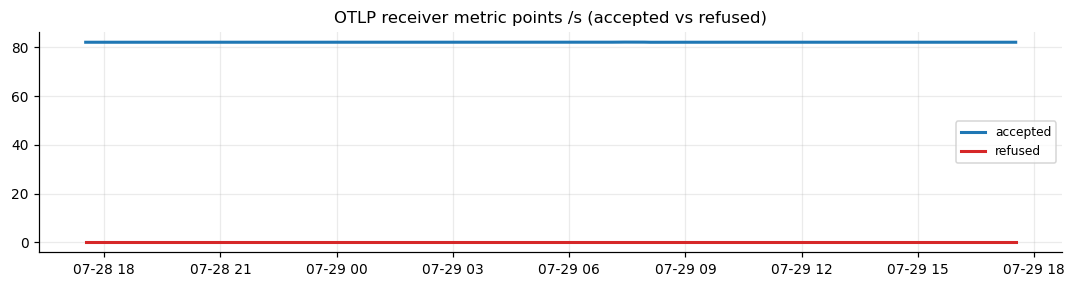

In [8]:
# --- OTLP RECEIVER: the edge (Synology/Proxmox) ingest door ---
print(f"otelcol receiver: metrics {otel_acc_m:,.1f}/s accepted, {otel_ref_m:.3f}/s refused; "
      f"logs {otel_acc_l:,.3f}/s accepted, {otel_ref_l:.3f}/s refused")
print("  (refused > 0 means edge data is bouncing at the door; accepted ~ 0 means the edge "
      "feeds went silent -- cross-check with the synology/proxmox ingestion notebooks)")

fig, ax = plt.subplots(figsize=(12, 2.6))
if not f_otel.empty:
    for c in f_otel.columns:
        ax.plot(f_otel.index, f_otel[c], lw=2, label=c, color='C0' if c == 'accepted' else 'C3')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'no OTLP receiver traffic in window', ha='center', va='center',
            transform=ax.transAxes, color='0.4')
    ax.grid(False)
ax.set_title('OTLP receiver metric points /s (accepted vs refused)')
nbc.show(fig)

In [9]:
# --- SCRAPE TARGETS & BLACKBOX PROBES: the scrape-in world ---
targets_down = sorted({f"{r['metric'].get('job', '?')}/{r['metric'].get('instance', '?')}"
                       for r in targets_down_q})
print(f"scrape targets: {int(targets_up)} up, {len(targets_down)} down")
for t in targets_down:
    print(f"  DOWN: {t}")

probes = {r['metric'].get('instance', r['metric'].get('target', '?')): int(float(r['value'][1]))
          for r in probe_success}
probes_down = sorted(t for t, ok in probes.items() if ok == 0)
print(f"blackbox probes: {sum(probes.values())}/{len(probes)} succeeding")
for t in probes_down:
    print(f"  PROBE FAILING: {t}")

scrape targets: 104 up, 1 down
  DOWN: mimir/gateway/10.0.148.117:8080
blackbox probes: 1/3 succeeding
  PROBE FAILING: http://hubitat.local.symmatree.com
  PROBE FAILING: https://morpheus.local.symmatree.com/


log lines/s by detected_level (mean over 24h): {'error': 0.42, 'info': 0.44, 'unknown': 0.06, 'warn': 0.02}


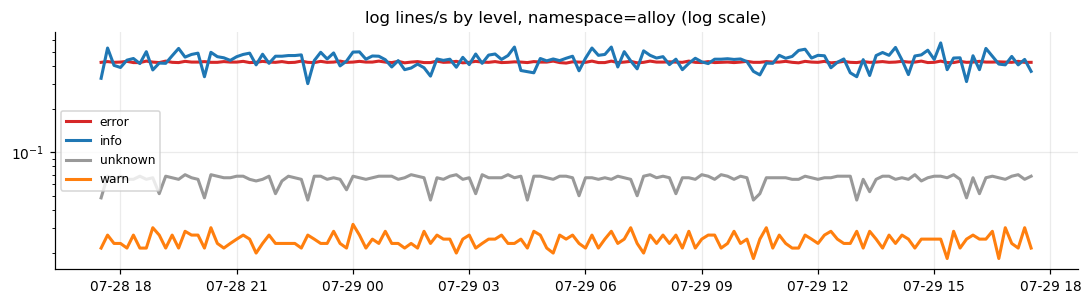

newest error/warn lines (up to 50 in 24h window, newest first):
  29 17:31:24 alloy-alloy-singleton-6bb9d87c89-q level=error ts=2026-07-29T17:31:24.841833974Z caller=runutil.go:117 msg="function failed. Retrying in next tick" err="trigger reload: reload
  29 17:31:24 alloy-alloy-singleton-84894dfdb8-g level=error ts=2026-07-29T17:31:24.270109469Z caller=runutil.go:117 msg="function failed. Retrying in next tick" err="trigger reload: reload
  29 17:31:23 alloy-alloy-metrics-0              I0729 17:31:23.253319       1 warnings.go:110] "Warning: v1 Endpoints is deprecated in v1.33+; use discovery.k8s.io/v1 EndpointSlice"
  29 17:31:23 alloy-alloy-metrics-0              I0729 17:31:23.060256       1 warnings.go:110] "Warning: v1 Endpoints is deprecated in v1.33+; use discovery.k8s.io/v1 EndpointSlice"
  29 17:31:19 alloy-alloy-singleton-6bb9d87c89-q level=error ts=2026-07-29T17:31:19.844880941Z caller=runutil.go:117 msg="function failed. Retrying in next tick" err="trigger reload: reload


In [10]:
# --- LOGS (Alloy's own): volume by level, error/warn sample ---
lvl_colors = {'error': 'C3', 'warn': 'C1', 'info': 'C0', 'debug': 'C4', 'unknown': '0.6'}
lvl_rate_mean = {c: round(float(f_loglevel[c].mean() / 600), 2) for c in f_loglevel.columns} if not f_loglevel.empty else {}
print(f"log lines/s by detected_level (mean over {lookback_hours}h): {lvl_rate_mean}")

fig, ax = plt.subplots(figsize=(12, 2.8))
if f_loglevel.empty:
    ax.text(0.5, 0.5, 'no log volume in window', ha='center', va='center', transform=ax.transAxes, color='0.4')
    ax.grid(False)
else:
    for c in f_loglevel.columns:
        ax.plot(f_loglevel.index, f_loglevel[c] / 600, lw=2, label=c, color=lvl_colors.get(c, '0.3'))
    ax.legend(fontsize=8)
    ax.set_yscale('log')
ax.set_title(f'log lines/s by level, namespace={namespace} (log scale)')
nbc.show(fig)

errish = sum(f_loglevel.get(lvl, pd.Series(dtype=float)).sum() for lvl in ('error', 'warn'))
if errish > 0 and not log_errwarn:
    print("WARNING: level counts report error/warn lines but the sample query returned none "
          "-- the sample query is broken, do not read this as 'no errors'")
print(f"newest error/warn lines (up to 50 in {lookback_hours}h window, newest first):")
for ts, st, line in log_errwarn[:30]:
    print(f"  {ts:%d %H:%M:%S} {st.get('pod', st.get('detected_level', '?'))[:34]:<34} {line[:140]}")
if len(log_errwarn) > 30:
    print(f"  ... {len(log_errwarn) - 30} more captured (see raw capture)")

In [11]:
# --- LOGS: raw tail -- unfiltered cross-check that collection is alive ---
print(f"last {len(log_tail)} lines of anything from namespace={namespace}, newest first:")
for ts, st, line in log_tail:
    print(f"  {ts:%H:%M:%S} {st.get('pod', '?')[:34]:<34} {line[:140]}")

last 100 lines of anything from namespace=alloy, newest first:
  17:31:24 alloy-alloy-singleton-6bb9d87c89-q level=error ts=2026-07-29T17:31:24.841833974Z caller=runutil.go:117 msg="function failed. Retrying in next tick" err="trigger reload: reload
  17:31:24 alloy-alloy-singleton-84894dfdb8-g level=error ts=2026-07-29T17:31:24.270109469Z caller=runutil.go:117 msg="function failed. Retrying in next tick" err="trigger reload: reload
  17:31:23 alloy-alloy-metrics-0              I0729 17:31:23.253319       1 warnings.go:110] "Warning: v1 Endpoints is deprecated in v1.33+; use discovery.k8s.io/v1 EndpointSlice"
  17:31:23 alloy-alloy-metrics-0              I0729 17:31:23.060256       1 warnings.go:110] "Warning: v1 Endpoints is deprecated in v1.33+; use discovery.k8s.io/v1 EndpointSlice"
  17:31:19 alloy-alloy-singleton-6bb9d87c89-q level=error ts=2026-07-29T17:31:19.844880941Z caller=runutil.go:117 msg="function failed. Retrying in next tick" err="trigger reload: reload
  17:31:19 alloy

In [12]:
# --- SUMMARY: assumption ledger first, then findings vs explicit thresholds ---
findings = []
if crashloopers:
    findings.append(f"pods in CrashLoopBackOff: {crashloopers}")
if oom_pods:
    findings.append(f"last termination OOMKilled: {oom_pods}")
if unhealthy > 0:
    findings.append(f"{unhealthy} unhealthy alloy components (on { {p for p in comp_unhealthy_by_pod} })")
hot = {p: round(v, 0) for p, v in (100 * pods['mem_mb'] / pods['limit_mb']).dropna().items() if v > 90}
if hot:
    findings.append(f"memory >90% of limit: {hot}")
if rw_failed > 0:
    findings.append(f"remote_write sample failures ({rw_failed:.3f}/s) -- samples not reaching Mimir")
if not np.isinf(rw_lag) and rw_lag > 120:
    findings.append(f"remote_write lag {rw_lag:.0f}s (>120s) -- write path backing up")
if loki_dropped > 0:
    findings.append(f"loki.write dropped entries ({loki_dropped:.3f}/s) -- lost logs")
if otel_ref_m > 0 or otel_ref_l > 0:
    findings.append(f"OTLP receiver refusing edge data (metrics {otel_ref_m:.3f}/s, logs {otel_ref_l:.3f}/s)")
if targets_down:
    findings.append(f"scrape targets down: {targets_down}")
if probes_down:
    findings.append(f"blackbox probes failing: {probes_down}")
ns_24h = {r['metric'].get('alertname', '?'): int(float(r['value'][1])) for r in alerts_ns_24h}
if ns_24h:
    findings.append(f"alerts fired in namespace {namespace} in 24h: {sorted(ns_24h)}")

print("=" * 60)
print("ALLOY HEALTH SUMMARY")
print("=" * 60)
print(f"run:      {cap.run_at}  ({cap.mode})")
print(f"alloy:    {alloy_version}, {alloy_instances} instances, tenant {tenant}, lookback {lookback_hours}h")
print()
print("Assumptions: " + ("all instruments fresh" if not assumption_warnings else "; ".join(assumption_warnings)))
print()
if findings:
    print("Findings:")
    for f in findings:
        print(f"  ! {f}")
else:
    print("Findings: none -- components healthy, write paths keeping up, edge door open, "
          "scrapes and probes green")
print()
print(f"  Components:  {healthy} healthy / {unhealthy} unhealthy; crashloops {crashloopers or 'none'}")
print(f"  Write-out:   rw {rw_failed:.3f}/s failed, lag {rw_lag:.0f}s; loki {loki_dropped:.3f}/s dropped")
print(f"  Edge in:     {otel_acc_m:,.1f}/s metric pts accepted, {otel_ref_m:.3f}/s refused")
print(f"  Scrape/probe: {len(targets_down)} targets down, {len(probes_down)} probes failing")

ALLOY HEALTH SUMMARY
run:      2026-07-29T17:31:25.789613+00:00  (live)
alloy:    v1.12.1, 10 instances, tenant tiles, lookback 24h

Assumptions: all instruments fresh

Findings:
  ! pods in CrashLoopBackOff: ['alloy-alloy-singleton-6bb9d87c89-qctbn', 'alloy-alloy-singleton-84894dfdb8-gpkff']
  ! last termination OOMKilled: ['alloy-alloy-metrics-0']
  ! 8 unhealthy alloy components (on {'alloy-alloy-logs-xkpvc', 'alloy-alloy-logs-wtnh5', 'alloy-alloy-logs-56lvd', 'alloy-alloy-logs-7hwcs', 'alloy-alloy-logs-vptfn', 'alloy-alloy-logs-fs5d9', 'alloy-alloy-logs-d2d5j', 'alloy-alloy-logs-fw8r5'})
  ! scrape targets down: ['mimir/gateway/10.0.148.117:8080']
  ! blackbox probes failing: ['http://hubitat.local.symmatree.com', 'https://morpheus.local.symmatree.com/']
  ! alerts fired in namespace alloy in 24h: ['KubeDeploymentReplicasMismatch', 'KubeDeploymentRolloutStuck', 'KubePodCrashLooping', 'UnhealthyComponents']

  Components:  154 healthy / 8 unhealthy; crashloops ['alloy-alloy-singleto

In [13]:
# AGENT-READABLE STATS -- consolidated JSON; assumption status leads.
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb',
    'run_at': cap.run_at,
    'mode': cap.mode,
    'alloy_version': alloy_version,
    'alloy_instances': alloy_instances,
    'lookback_hours': lookback_hours,
    'assumptions': {'status': 'ok' if not assumption_warnings else 'degraded',
                    'warnings': assumption_warnings,
                    'instrument_age_s': {k: _n(v) for k, v in inst_age.items()}},
    'findings': findings,
    'components': {'healthy': healthy, 'unhealthy': unhealthy,
                   'unhealthy_by_pod': {p: int(v) for p, v in comp_unhealthy_by_pod.items()},
                   'crashloop': crashloopers, 'oom_last_term': oom_pods,
                   'restarts_by_pod': {p: int(n) for p, n in pods['restarts'].items() if n > 0}},
    'remote_write': {'samples_failed_per_s': _n(rw_failed), 'samples_pending': _n(rw_pending),
                     'shards': _n(rw_shards), 'lag_s': _n(rw_lag)},
    'loki_write': {'entries_per_s_sent': _n(loki_sent), 'dropped_per_s': _n(loki_dropped),
                   'batch_retries_per_s': _n(loki_retries)},
    'otlp_receiver': {'metrics_accepted_per_s': _n(otel_acc_m), 'metrics_refused_per_s': _n(otel_ref_m),
                      'logs_accepted_per_s': _n(otel_acc_l), 'logs_refused_per_s': _n(otel_ref_l)},
    'scrape': {'targets_up': _n(targets_up), 'targets_down': targets_down},
    'probes': {'succeeding': sum(probes.values()), 'total': len(probes), 'failing': probes_down},
    'alerts': {'namespace_24h': ns_24h},
    'logs': {'lines_per_s_mean_by_level': lvl_rate_mean, 'errwarn_captured': len(log_errwarn),
             'errwarn_newest': [f"{ts:%Y-%m-%d %H:%M:%S} {st.get('pod', '?')} {line[:150]}"
                                for ts, st, line in log_errwarn[:10]]},
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "alloy-health.ipynb",
 "run_at": "2026-07-29T17:31:25.789613+00:00",
 "mode": "live",
 "alloy_version": "v1.12.1",
 "alloy_instances": 10,
 "lookback_hours": 24,
 "assumptions": {
  "status": "ok",
  "warnings": [],
  "instrument_age_s": {
   "alloy self-monitoring": 12.4766,
   "kube-state-metrics (alloy ns)": 48.3726,
   "cadvisor (alloy ns)": 2.0416,
   "alloy (alloy ns logs)": 1.5193
  }
 },
 "findings": [
  "pods in CrashLoopBackOff: ['alloy-alloy-singleton-6bb9d87c89-qctbn', 'alloy-alloy-singleton-84894dfdb8-gpkff']",
  "last termination OOMKilled: ['alloy-alloy-metrics-0']",
  "8 unhealthy alloy components (on {'alloy-alloy-logs-xkpvc', 'alloy-alloy-logs-wtnh5', 'alloy-alloy-logs-56lvd', 'alloy-alloy-logs-7hwcs', 'alloy-alloy-logs-vptfn', 'alloy-alloy-logs-fs5d9', 'alloy-alloy-logs-d2d5j', 'alloy-alloy-logs-fw8r5'})",
  "scrape targets down: ['mimir/gateway/10.0.148.117:8080']",
  "blackbox probes failing: ['http://hubitat.local.symmatree.com', 'https://morpheus.l